# G-DAE training

This notebook builds the K2-18b-like training set and trains the dense General
Denoising AutoEncoder (G-DAE) used by the sub-Neptune workflow. The model learns
to map contaminated and noisy spectra back to their clean spectra.

In [1]:
from __future__ import annotations

import gc
import glob
import os
import re
import tempfile
import warnings
from pathlib import Path
from typing import Dict, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pandexo.engine.justdoit as jdi

from sklearn.model_selection import train_test_split


def remove_warnings() -> None:
    """Silence deprecation warnings to keep notebook output readable."""
    warnings.filterwarnings("ignore", category=DeprecationWarning)


remove_warnings()

## Run configuration

The generated dataset can be large, so the notebook reuses it when available.
Set `REBUILD_DATASET = False` to force a fresh dataset build, and set
`TRAIN_MODEL = False` to retrain and overwrite `AE.keras`.

In [2]:
SPECTRA_PATH = Path("specs/K2-18b_data.joblib")
DATASET_NPZ = Path("k218_autoencoder_dataset.npz")
MODEL_PATH = Path("AE.keras")

REF_FLAT = 0.0023243496509944973
LOG_RATIO_EPS = 1e-12
EXPECTED_CONTRACT = "log_ratio_ref_flat_v1"

# The previous cached dataset/model were built with row-wise min-max normalization.
# After switching the contract to log(depth / ref_flat), rebuild/retrain by default.
REBUILD_DATASET = False
TRAIN_MODEL = False


In [3]:
waves = np.loadtxt("waves.txt", dtype=float)
n_points = int(len(waves))


wn_grid = np.sort(10000.0 / waves)

print("n_points:", n_points)
print("waves range [um]:", float(waves.min()), "-", float(waves.max()))

n_points: 385
waves range [um]: 0.698805 - 5.297569


In [4]:
def attach_spectrum_blocks(df: pd.DataFrame, n_points: int) -> pd.DataFrame:
    """Attach `.data` and `.params` views using the last `n_points` columns."""
    object.__setattr__(df, "data", df.iloc[:, -n_points:])
    object.__setattr__(df, "params", df.iloc[:, :-n_points])
    return df


def spectrum_block_to_numpy(df: pd.DataFrame, n_points: int) -> np.ndarray:
    """Extract the spectral block as a standalone float32 array."""
    return df.iloc[:, -n_points:].to_numpy(dtype=np.float32, copy=True)


def infer_ref_flat_from_flat(
    flat_df: pd.DataFrame,
    n_points: int,
    atol: float = 1e-12,
    rtol: float = 1e-8,
) -> float:
    """Infer a scalar flat reference depth from the clean flat spectrum."""
    flat_values = spectrum_block_to_numpy(flat_df, n_points)[0]
    ref_flat = float(np.median(flat_values))

    if not np.allclose(flat_values, ref_flat, atol=atol, rtol=rtol):
        raise ValueError("Flat reference spectrum is not constant enough to define scalar ref_flat.")
    if not np.isfinite(ref_flat) or ref_flat <= 0.0:
        raise ValueError(f"Invalid ref_flat inferred from flat spectrum: {ref_flat}")

    return ref_flat


def to_log_ratio(values, ref_flat, eps: float = LOG_RATIO_EPS):
    """Transform physical transit depths to log(depth / ref_flat)."""
    ref_flat = float(ref_flat)
    if not np.isfinite(ref_flat) or ref_flat <= 0.0:
        raise ValueError(f"ref_flat must be a positive finite float, got {ref_flat}")

    arr = np.asarray(values, dtype=np.float32)
    arr = np.clip(arr, eps, None)
    return np.log(arr / ref_flat).astype(np.float32)


def from_log_ratio(values_log, ref_flat):
    """Map log(depth / ref_flat) back to physical transit depths."""
    ref_flat = float(ref_flat)
    if not np.isfinite(ref_flat) or ref_flat <= 0.0:
        raise ValueError(f"ref_flat must be a positive finite float, got {ref_flat}")

    arr = np.asarray(values_log, dtype=np.float32)
    return (np.exp(arr) * ref_flat).astype(np.float32)


def apply_contaminations_from_files(
    contamination_files: list[str],
    df: pd.DataFrame,
    n_points: int,
    include_no_contam: bool = False,
) -> np.ndarray:
    """
    Apply multiplicative stellar contamination epsilon(lambda) from a list of text files.

    Parameters
    ----------
    contamination_files
        Paths to .txt files. Expected suffix pattern: fspot<val>_ffac<val>.txt
        Example: epsilon_T3400_fspot0.000_ffac0.000.txt
    df
        Input dataframe containing spectra in the last n_points columns.
    n_points
        Number of spectral columns at the end of df to contaminate.
    include_no_contam
        If True, prepend an explicit uncontaminated copy and skip the (0,0)
        file if it exists to avoid duplication.

    Returns
    -------
    np.ndarray
        Spectral array containing all contaminated realizations.
    """
    base_spectra = spectrum_block_to_numpy(df, n_points)
    contaminated_blocks: list[np.ndarray] = []

    if include_no_contam:
        contaminated_blocks.append(base_spectra.copy())

    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"The file {file_path} does not exist.")

        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if not match:
            raise ValueError(f"The file name '{filename}' does not match the expected pattern.")

        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        if include_no_contam and f_spot == 0.0 and f_fac == 0.0:
            continue

        contamination_data = np.loadtxt(file_path, ndmin=2)

        if contamination_data.shape[1] >= 2:
            contam_values = contamination_data[:, 1]
        else:
            contam_values = contamination_data.flatten()

        if len(contam_values) != n_points:
            raise ValueError(
                f"The number of contamination values in '{filename}' ({len(contam_values)}) "
                f"does not match n_points ({n_points})."
            )

        contam_values = contam_values[::-1]
        contaminated_blocks.append(
            (base_spectra * contam_values[np.newaxis, :]).astype(np.float32, copy=False)
        )

    if not contaminated_blocks:
        raise ValueError("No contamination blocks were generated.")

    return np.vstack(contaminated_blocks).astype(np.float32, copy=False)


## Load base dataset and create a flat reference spectrum

The base spectra come from `01_Spectra_Generation.ipynb`. A flat reference
spectrum is added so the denoising model also sees spectra without molecular
features.

In [5]:
k2_18b = joblib.load(SPECTRA_PATH)

gas_cols = ["atm CO2", "atm CH4", "atm H2O", "atm NH3"]
k2_18b[gas_cols] = k2_18b[gas_cols].fillna(0)

flat = k2_18b[
    (k2_18b["atm CO2"] == -10)
    & (k2_18b["atm CH4"] == 0)
    & (k2_18b["atm H2O"] == 0)
    & (k2_18b["atm NH3"] == 0)
].iloc[0:1].copy()

flat["atm CO2"] = 0
flat.iloc[0, -n_points:] = 0.0023243496509944973

attach_spectrum_blocks(flat, n_points)

spectral_columns = np.asarray(k2_18b.columns[-n_points:], dtype=float)
np.testing.assert_allclose(spectral_columns, np.asarray(waves[::-1], dtype=float))
print("Spectral columns are aligned with waves[::-1].")

print("k2_18b shape:", k2_18b.shape)
print("flat.data shape:", flat.data.shape)
print("flat.params shape:", flat.params.shape)


Spectral columns are aligned with waves[::-1].
k2_18b shape: (22050, 407)
flat.data shape: (1, 385)
flat.params shape: (1, 22)


## Apply stellar contamination curves

The `TLS/epsilon_*.txt` files are generated by `02_Stellar_Contamination.ipynb`.
Each curve is multiplied into the clean spectra to create the contaminated
training inputs.

In [6]:
contamination_files = sorted(glob.glob("TLS/epsilon_T*_fspot*_ffac*.txt"))
print("N contamination files found:", len(contamination_files))

k2_18b_contam_data = apply_contaminations_from_files(
    contamination_files,
    k2_18b,
    n_points=n_points,
)

flat_contam_data = apply_contaminations_from_files(
    contamination_files,
    flat,
    n_points=n_points,
)

print("k2_18b_contam_data:", k2_18b_contam_data.shape)
print("flat_contam_data:", flat_contam_data.shape)


N contamination files found: 48
k2_18b_contam_data: (1058400, 385)
flat_contam_data: (48, 385)


In [7]:
def mult_spectra_array(df: pd.DataFrame, n_points: int, n_mult: int) -> np.ndarray:
    """Repeat clean spectra so they align with the contaminated cases."""
    base_spectra = spectrum_block_to_numpy(df, n_points)
    return np.tile(base_spectra, (int(n_mult) + 1, 1)).astype(np.float32, copy=False)


n_mult = int(len(contamination_files) - 1)

k2_18b_mult_data = mult_spectra_array(k2_18b, n_points=n_points, n_mult=n_mult)
flat_mult_data = mult_spectra_array(flat, n_points=n_points, n_mult=n_mult)

ref_flat = float(REF_FLAT) if REF_FLAT is not None else infer_ref_flat_from_flat(flat, n_points)
print(f"Using ref_flat = {ref_flat:.12e}")

flat_reference = spectrum_block_to_numpy(flat, n_points)[0]
flat_roundtrip = from_log_ratio(to_log_ratio(flat_reference, ref_flat), ref_flat)
np.testing.assert_allclose(flat_roundtrip, flat_reference, rtol=1e-6, atol=1e-12)

print("k2_18b_contam_data:", k2_18b_contam_data.shape)
print("flat_contam_data:", flat_contam_data.shape)
print("k2_18b_mult_data:", k2_18b_mult_data.shape)
print("flat_mult_data:", flat_mult_data.shape)


Using ref_flat = 2.324349650994e-03
k2_18b_contam_data: (1058400, 385)
flat_contam_data: (48, 385)
k2_18b_mult_data: (1058400, 385)
flat_mult_data: (48, 385)


### Quick plot: contaminated flat vs clean flat

This is a sanity check that:
- contamination modifies the flat spectrum as expected
- the clean flat reference stays constant

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


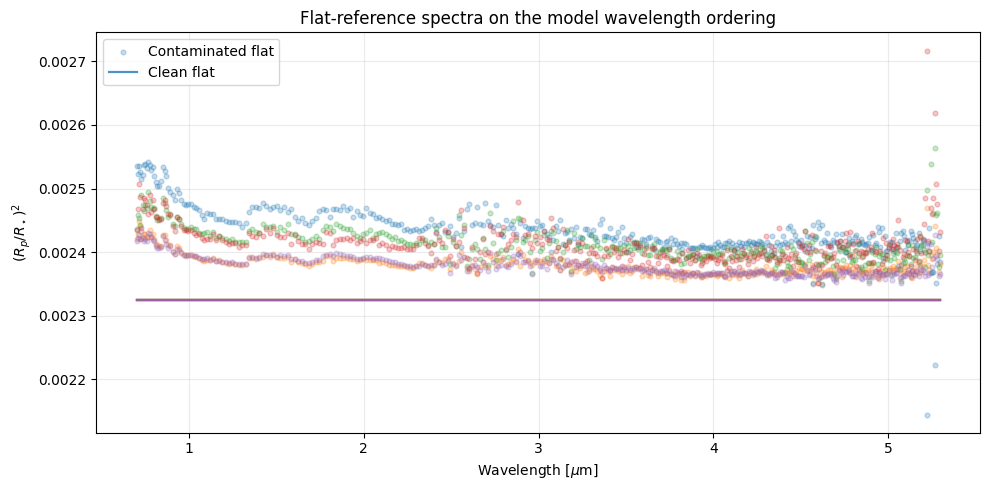

In [8]:
wavelength_axis = np.asarray(waves[::-1], dtype=float)

plt.figure(figsize=(10, 5))

for draw_idx in range(5):
    sample_idx = np.random.randint(0, flat_contam_data.shape[0])
    plt.scatter(
        wavelength_axis,
        flat_contam_data[sample_idx].astype(float),
        alpha=0.25,
        s=12,
        label="Contaminated flat" if draw_idx == 0 else None,
    )
    plt.plot(
        wavelength_axis,
        flat_mult_data[sample_idx].astype(float),
        alpha=0.8,
        linewidth=1.6,
        label="Clean flat" if draw_idx == 0 else None,
    )

plt.xlabel(r"Wavelength [$\mu$m]")
plt.ylabel(r"$(R_p/R_\star)^2$")
plt.title("Flat-reference spectra on the model wavelength ordering")
plt.grid(True, alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.show()


## PandExo instrument noise for K2-18b / NIRSpec Prism

PandExo provides the wavelength-dependent instrumental uncertainty profile used
as the Gaussian noise scale. The profile is computed for a flat transit-depth
spectrum and then interpolated onto the training grid.

In [9]:
MAG_J_K218 = 9.763
TSTAR_K218 = 3500.0
LOGG_K218 = 4.6
MET_K218 = 0.0
TTRANS_H_K218 = 2.682

DEPTH_K218 = 0.0023243496509944973


def get_k218_prism_noise_flat(
    wl_grid_um: np.ndarray,
    depth_rp2_rs2: float = DEPTH_K218,
    n_transits: int = 10,
    T_s: float = TSTAR_K218,
    transit_duration_hours: float = TTRANS_H_K218,
    plot: bool = False,
    cut_first: int = 20,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return a representative JWST/NIRSpec Prism instrument noise curve sigma_inst(lambda)
    using PandExo for a flat transit depth spectrum.

    Returns
    -------
    waves_trim, errors_trim
        Trimmed wavelength grid (um) and error_w_floor (same length).
    """
    wl_grid_um = np.asarray(wl_grid_um, dtype=float)
    depth_arr = np.full_like(wl_grid_um, depth_rp2_rs2, dtype=float)

    tmp_path: str | None = None
    try:
        with tempfile.NamedTemporaryFile(mode="w", suffix=".txt", delete=False) as tmp:
            tmp_path = tmp.name
            np.savetxt(tmp, np.column_stack([wl_grid_um, depth_arr]))

        exo = jdi.load_exo_dict()

        transit_duration_sec = float(transit_duration_hours) * 3600.0
        baseline_sec = 3.0 * transit_duration_sec

        exo["observation"].update(
            {
                "sat_level": 80,
                "sat_unit": "%",
                "baseline_unit": "total",
                "baseline": baseline_sec,
                "noise_floor": 0,
                "noccultations": int(n_transits),
            }
        )

        exo["star"].update(
            {
                "type": "phoenix",
                "mag": MAG_J_K218,
                "ref_wave": 1.25,
                "temp": float(T_s),
                "metal": MET_K218,
                "logg": LOGG_K218,
            }
        )

        exo["planet"].update(
            {
                "type": "user",
                "w_unit": "um",
                "f_unit": "rp^2/r*^2",
                "transit_duration": transit_duration_sec,
                "td_unit": "s",
                "exopath": tmp_path,
            }
        )

        inst = jdi.load_mode_dict("NIRSpec Prism")
        inst["configuration"]["detector"].update({"subarray": "sub512", "ngroup": 6})

        results = jdi.run_pandexo(exo, inst)

        waves_full = results["FinalSpectrum"]["wave"]
        flux_full = results["FinalSpectrum"]["spectrum"]
        errors_full = results["FinalSpectrum"]["error_w_floor"]

        if cut_first > 0:
            waves_trim = waves_full[cut_first:]
            flux_trim = flux_full[cut_first:]
            errors_trim = errors_full[cut_first:]
        else:
            waves_trim = waves_full
            flux_trim = flux_full
            errors_trim = errors_full

        if plot:
            plt.figure(figsize=(8, 4))
            plt.errorbar(
                waves_trim,
                flux_trim,
                yerr=errors_trim,
                fmt="o",
                ms=4,
                elinewidth=1,
                capsize=2,
            )
            plt.xlabel("Wavelength (um)")
            plt.ylabel(r"Transit depth $(R_p/R_*)^2$")
            plt.title(f"PandExo K2-18b - {n_transits} transits, T*={T_s:.0f} K")
            plt.tight_layout()
            plt.show()

    finally:
        if tmp_path is not None and os.path.exists(tmp_path):
            os.remove(tmp_path)

    return waves_trim, errors_trim

In [10]:
wl_base = np.linspace(0.6, 5.3, 1000)

sigma_by_T: Dict[int, np.ndarray] = {}
for T in [1, 2, 4]:
    _, sigma_T = get_k218_prism_noise_flat(
        wl_grid_um=wl_base,
        n_transits=T,
        T_s=3500.0,
        plot=False,
        cut_first=18,
    )
    sigma_by_T[T] = sigma_T[::-1]

n_points = int(sigma_by_T[1].shape[0])

assert k2_18b_mult_data.shape[1] == n_points
assert k2_18b_contam_data.shape[1] == n_points
assert flat_mult_data.shape[1] == n_points
assert flat_contam_data.shape[1] == n_points

print("n_points (final, from sigma_inst):", n_points)


Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]
c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:


End out of Transit
Starting In Transit Simulation
End In Transit
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
n_points (final, from sigma_inst): 385


In [11]:
def generate_noisy_spectra_array(
    spectra: np.ndarray,
    n_repeat: int,
    noise_std: float | np.ndarray,
    seed: int | None = None,
) -> np.ndarray:
    """
    Replicate the spectral block and add Gaussian noise directly in NumPy.

    Parameters
    ----------
    spectra
        Spectral array with shape `(n_rows, n_wavelengths)`.
    n_repeat
        Number of repetitions per source spectrum.
    noise_std
        - scalar: same sigma everywhere
        - 1D length N_spectra: sigma per spectrum (copied to all wavelengths)
        - 1D length N_wavelengths: sigma per wavelength (same vector for all rows)
    seed
        Random seed.

    Returns
    -------
    np.ndarray
        Spectral array with shape `(n_rows * n_repeat, n_wavelengths)`.
    """
    if seed is not None:
        np.random.seed(int(seed))

    spectra = np.asarray(spectra, dtype=np.float32)
    if spectra.ndim != 2:
        raise ValueError(f"spectra must be 2D, got shape {spectra.shape}")

    n_spec, n_wl = spectra.shape
    spectra_rep = np.repeat(spectra, int(n_repeat), axis=0).astype(np.float32, copy=False)

    if isinstance(noise_std, (int, float)):
        sigma_value = float(noise_std)
        if sigma_value < 0:
            raise ValueError("noise_std must be non-negative.")
        if sigma_value > 0:
            spectra_rep += np.random.normal(
                loc=0.0,
                scale=sigma_value,
                size=spectra_rep.shape,
            ).astype(np.float32)

    else:
        noise_array = np.asarray(noise_std, dtype=np.float32)
        if noise_array.ndim != 1:
            raise ValueError("noise_std must be 1D if array-like.")
        if np.any(noise_array < 0):
            raise ValueError("All values in noise_std must be non-negative.")

        if len(noise_array) == n_spec:
            sigma = np.repeat(noise_array[:, np.newaxis], int(n_repeat), axis=0)
            sigma = np.tile(sigma, (1, n_wl)).astype(np.float32, copy=False)
        elif len(noise_array) == n_wl:
            sigma = np.tile(noise_array, (n_spec * int(n_repeat), 1)).astype(np.float32, copy=False)
        else:
            raise ValueError(
                "If noise_std is array-like, its length must be either "
                "N_spectra or N_wavelengths."
            )

        spectra_rep += np.random.normal(
            loc=0.0,
            scale=sigma,
            size=spectra_rep.shape,
        ).astype(np.float32)

        del sigma

    gc.collect()
    return spectra_rep


## Build dataset blocks per transit label

For each transit label, contaminated spectra receive the PandExo noise profile
and both inputs and targets are transformed to the new contract
`log(depth / ref_flat)`, using the scalar `ref_flat` inferred from the clean
flat spectrum unless it is specified manually above.


In [12]:
def build_block_for_T(
    T_label: float,
    sigma_T: np.ndarray | None,
    n_repeat_main: int,
    flat_factor: int,
    add_instrument_noise: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Build (X_noisy, X_clean, T_vec) for one transit label.

    Both inputs and targets follow the contract:
        log(depth / ref_flat)
    with a scalar reference inferred from the clean flat spectrum.
    """
    n_main = int(n_repeat_main)
    n_flat = int(n_repeat_main * flat_factor)

    if add_instrument_noise:
        noise_std_contam = sigma_T
    else:
        noise_std_contam = 0.0

    noisy_main = generate_noisy_spectra_array(
        spectra=k2_18b_contam_data,
        n_repeat=n_main,
        noise_std=noise_std_contam,
    )
    noisy_flat = generate_noisy_spectra_array(
        spectra=flat_contam_data,
        n_repeat=n_flat,
        noise_std=noise_std_contam,
    )

    spec_noisy = to_log_ratio(
        np.vstack([noisy_main, noisy_flat]).astype(np.float32, copy=False),
        ref_flat,
    )

    del noisy_main, noisy_flat
    gc.collect()

    clean_main = generate_noisy_spectra_array(
        spectra=k2_18b_mult_data,
        n_repeat=n_main,
        noise_std=0.0,
    )
    clean_flat = generate_noisy_spectra_array(
        spectra=flat_mult_data,
        n_repeat=n_flat,
        noise_std=0.0,
    )

    spec_clean = to_log_ratio(
        np.vstack([clean_main, clean_flat]).astype(np.float32, copy=False),
        ref_flat,
    )

    del clean_main, clean_flat
    gc.collect()

    if spec_noisy.shape != spec_clean.shape:
        raise ValueError(
            f"Shape mismatch between noisy and clean blocks: {spec_noisy.shape} vs {spec_clean.shape}"
        )

    T_vec = np.full(spec_noisy.shape[0], T_label, dtype=float)
    gc.collect()

    return spec_noisy, spec_clean, T_vec


## Assemble final arrays and save the dataset

When `REBUILD_DATASET` is true, this cell regenerates `k218_autoencoder_dataset.npz`.
Otherwise it reuses the existing file to avoid repeating the expensive dataset
construction step.

In [13]:
if REBUILD_DATASET:
    block_plan = [
        dict(T_label=1.0, sigma_T=sigma_by_T[1], n_repeat_main=5, flat_factor=100, add_instrument_noise=True),
        dict(T_label=2.0, sigma_T=sigma_by_T[2], n_repeat_main=5, flat_factor=100, add_instrument_noise=True),
        dict(T_label=4.0, sigma_T=sigma_by_T[4], n_repeat_main=5, flat_factor=100, add_instrument_noise=True),
        dict(T_label=np.nan, sigma_T=None, n_repeat_main=7, flat_factor=70, add_instrument_noise=False),
    ]

    rows_per_main = int(k2_18b_contam_data.shape[0])
    rows_per_flat = int(flat_contam_data.shape[0])
    total_rows = sum(
        rows_per_main * int(item["n_repeat_main"]) + rows_per_flat * int(item["n_repeat_main"] * item["flat_factor"])
        for item in block_plan
    )
    n_wl = int(k2_18b_contam_data.shape[1])

    temp_noisy_path = DATASET_NPZ.with_name(DATASET_NPZ.stem + "_X_noisy.tmp.npy")
    temp_clean_path = DATASET_NPZ.with_name(DATASET_NPZ.stem + "_X_clean.tmp.npy")
    temp_labels_path = DATASET_NPZ.with_name(DATASET_NPZ.stem + "_T_labels.tmp.npy")

    for temp_path in [temp_noisy_path, temp_clean_path, temp_labels_path]:
        if temp_path.exists():
            temp_path.unlink()

    X_noisy_mm = np.lib.format.open_memmap(temp_noisy_path, mode="w+", dtype=np.float32, shape=(total_rows, n_wl))
    X_clean_mm = np.lib.format.open_memmap(temp_clean_path, mode="w+", dtype=np.float32, shape=(total_rows, n_wl))
    T_labels_mm = np.lib.format.open_memmap(temp_labels_path, mode="w+", dtype=np.float64, shape=(total_rows,))

    write_head = 0
    for item in block_plan:
        Xn, Xc, Tl = build_block_for_T(
            T_label=item["T_label"],
            sigma_T=item["sigma_T"],
            n_repeat_main=item["n_repeat_main"],
            flat_factor=item["flat_factor"],
            add_instrument_noise=item["add_instrument_noise"],
        )

        next_head = write_head + Xn.shape[0]
        X_noisy_mm[write_head:next_head] = Xn
        X_clean_mm[write_head:next_head] = Xc
        T_labels_mm[write_head:next_head] = Tl

        print(
            f"Prepared T={item['T_label']}: rows {write_head}:{next_head} "
            f"({Xn.shape[0]:,} samples)"
        )

        write_head = next_head
        X_noisy_mm.flush()
        X_clean_mm.flush()
        T_labels_mm.flush()

        del Xn, Xc, Tl
        gc.collect()

    if write_head != total_rows:
        raise RuntimeError(f"Dataset write mismatch: wrote {write_head} rows, expected {total_rows}.")

    del X_noisy_mm, X_clean_mm, T_labels_mm
    gc.collect()

    X_noisy = np.load(temp_noisy_path, mmap_mode="r")
    X_clean = np.load(temp_clean_path, mmap_mode="r")
    T_labels = np.load(temp_labels_path, mmap_mode="r")

    print("Final shapes:", X_noisy.shape, X_clean.shape, T_labels.shape)
    assert X_noisy.shape == X_clean.shape

    np.savez(
        DATASET_NPZ,
        X_noisy=X_noisy,
        X_clean=X_clean,
        T_labels=T_labels,
        ref_flat=np.asarray(ref_flat, dtype=np.float32),
        contract=np.asarray(EXPECTED_CONTRACT),
    )
    print(f"Saved: {DATASET_NPZ}")

    del X_noisy, X_clean, T_labels
    gc.collect()

    for temp_path in [temp_noisy_path, temp_clean_path, temp_labels_path]:
        if temp_path.exists():
            temp_path.unlink()
else:
    print(f"Using existing dataset: {DATASET_NPZ}")

del k2_18b, flat, k2_18b_contam_data, flat_contam_data, k2_18b_mult_data, flat_mult_data, sigma_by_T
gc.collect()


Prepared T=1.0: rows 0:5316000 (5,316,000 samples)
Prepared T=2.0: rows 5316000:10632000 (5,316,000 samples)
Prepared T=4.0: rows 10632000:15948000 (5,316,000 samples)
Prepared T=nan: rows 15948000:23380320 (7,432,320 samples)
Final shapes: (23380320, 385) (23380320, 385) (23380320,)
Saved: k218_autoencoder_dataset.npz


0

In [11]:
dataset = np.load(DATASET_NPZ)
dataset_contract = str(dataset["contract"]) if "contract" in dataset.files else "legacy_min_max"
if dataset_contract != EXPECTED_CONTRACT:
    raise RuntimeError(
        f"Dataset contract mismatch: found '{dataset_contract}', expected '{EXPECTED_CONTRACT}'. "
        "Rebuild the dataset with REBUILD_DATASET = False."
    )

X_noisy = dataset["X_noisy"]
X_clean = dataset["X_clean"]
T_labels = dataset["T_labels"]
ref_flat = float(dataset["ref_flat"]) if "ref_flat" in dataset.files else ref_flat

del dataset
gc.collect()

print("Loaded:", X_noisy.shape, X_clean.shape, T_labels.shape)
print(f"Dataset contract: {dataset_contract}")
print(f"Using ref_flat = {ref_flat:.12e}")


Loaded: (23380320, 385) (23380320, 385) (23380320,)
Dataset contract: log_ratio_ref_flat_v1
Using ref_flat = 2.324349712580e-03


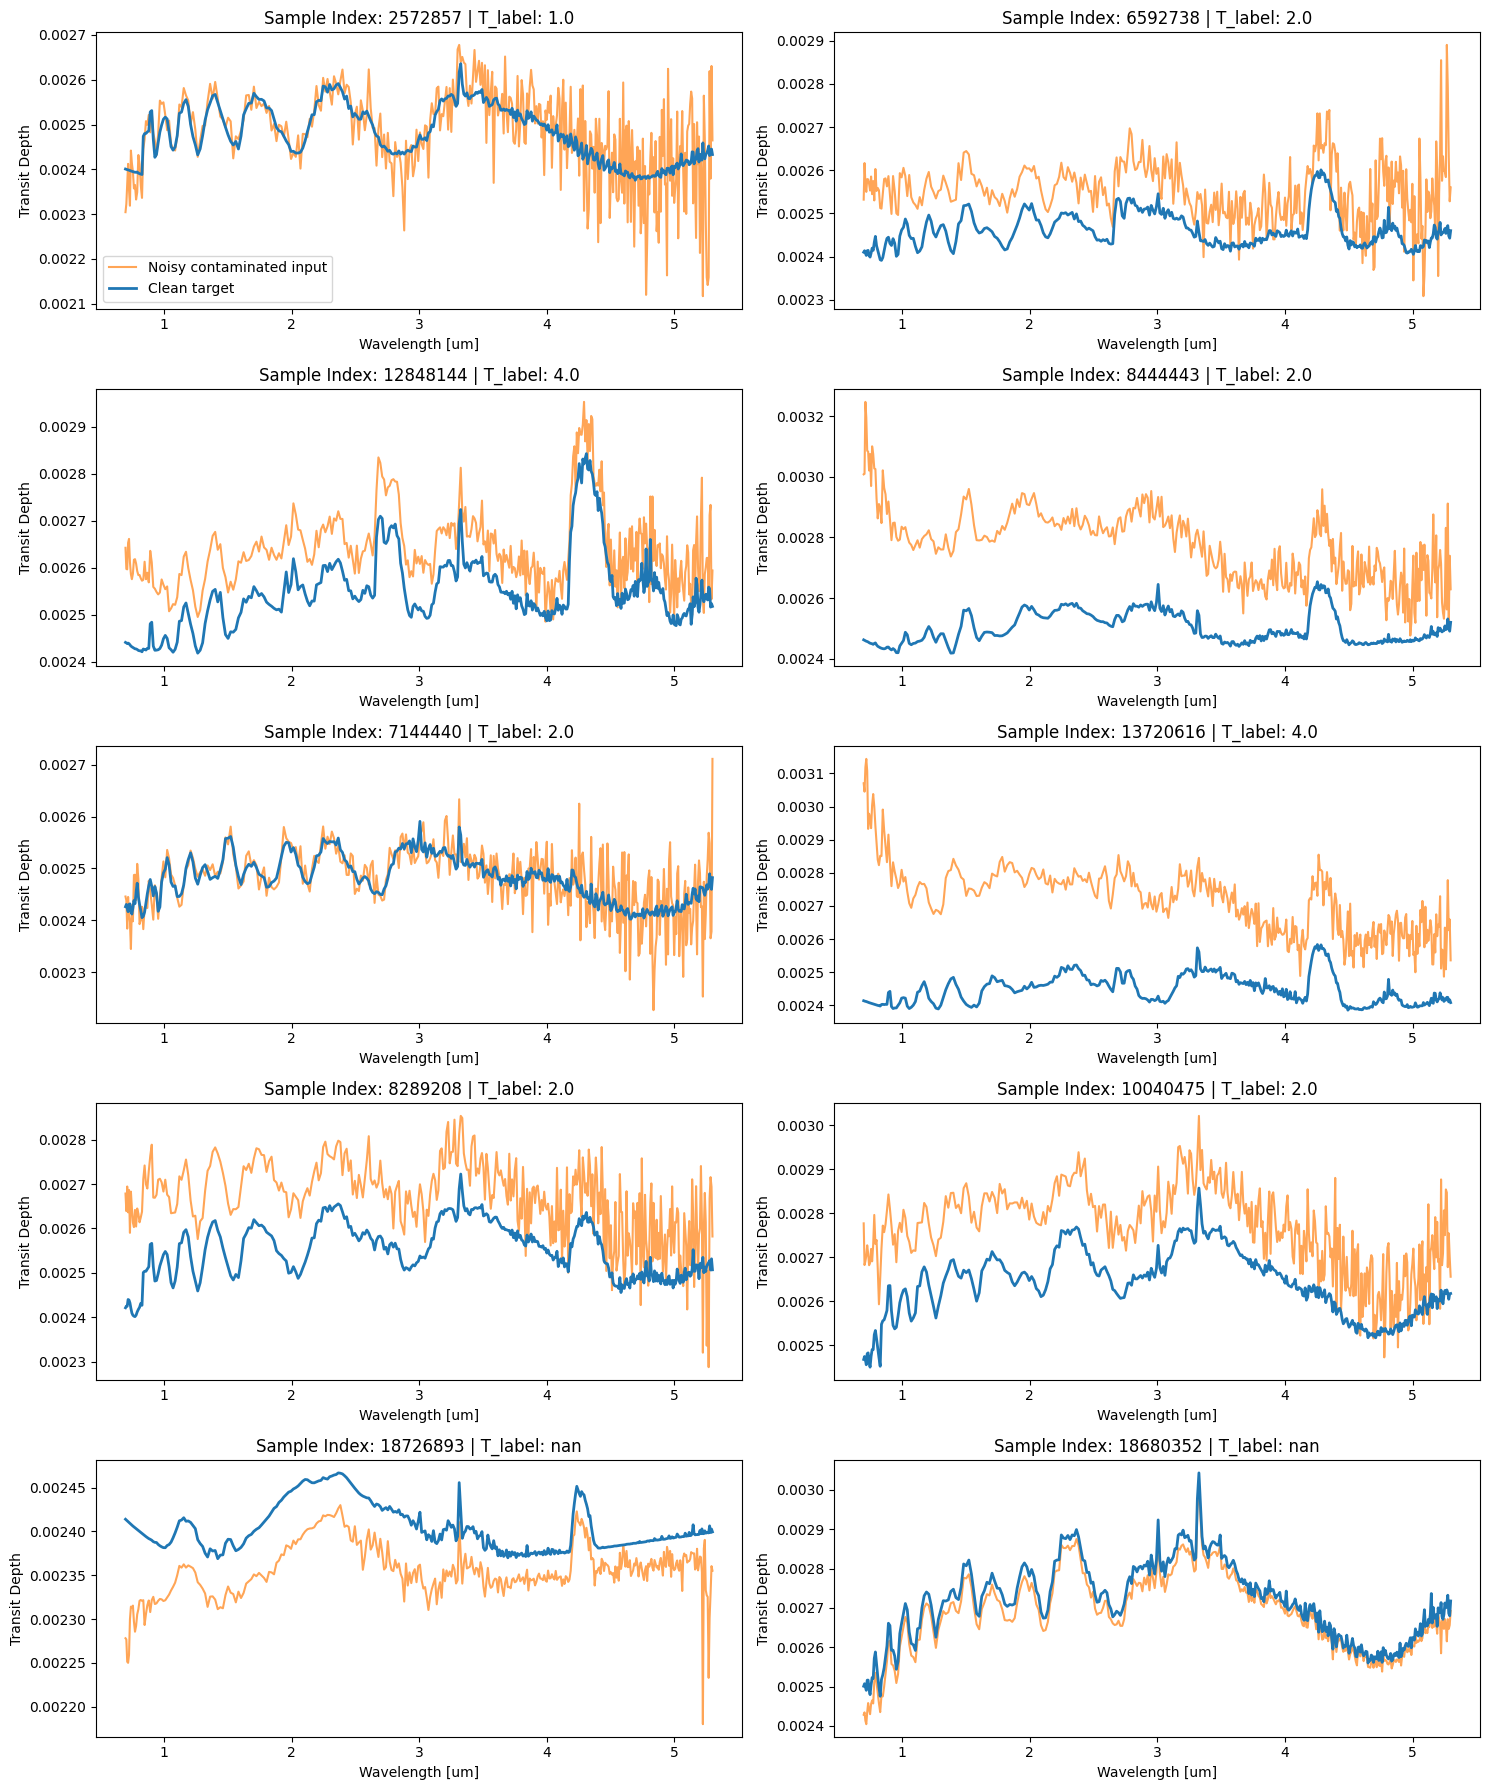

In [13]:
import matplotlib.pyplot as plt
import random

# Select 10 random indices to verify alignment
n_samples = 10
indices = random.sample(range(X_noisy.shape[0]), n_samples)

fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes = axes.flatten()

for i, idx in enumerate(indices):
    ax = axes[i]
    
    noisy_sample = from_log_ratio(X_noisy[idx], ref_flat)
    clean_sample = from_log_ratio(X_clean[idx], ref_flat)
    
    ax.plot(waves[::-1], noisy_sample, label='Noisy contaminated input', color='tab:orange', alpha=0.7)
    ax.plot(waves[::-1], clean_sample, label='Clean target', color='tab:blue', linewidth=2)
    
    ax.set_title(f'Sample Index: {idx} | T_label: {T_labels[idx]}')
    ax.set_xlabel('Wavelength [um]')
    ax.set_ylabel('Transit Depth')
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()


## Train/test split

In [18]:
test_size = 0.2

X_train_noisy, X_test_noisy, X_train_clean, X_test_clean = train_test_split(
    X_noisy,
    X_clean,
    test_size=test_size,
    random_state=42,
)

del X_noisy, X_clean
gc.collect()

print("Train:", X_train_noisy.shape, X_train_clean.shape)
print("Test :", X_test_noisy.shape, X_test_clean.shape)

Train: (18704256, 385) (18704256, 385)
Test : (4676064, 385) (4676064, 385)


## G-DAE architecture

In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

input_dim = int(X_train_noisy.shape[1])
l2_lambda = 1e-7

input_spectrum = keras.Input(shape=(input_dim,))

encoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(input_spectrum)
encoded = layers.Dropout(0.5)(encoded)
encoded = layers.Dense(512, activation="swish", kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
encoded = layers.Dropout(0.5)(encoded)
encoded = layers.Dense(512, activation="swish", kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
encoded = layers.Dropout(0.5)(encoded)
encoded = layers.Dense(300, activation="swish", kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
encoded = layers.Dropout(0.5)(encoded)
encoded = layers.Dense(300, activation="swish", kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
encoded = layers.Dropout(0.5)(encoded)

decoded = layers.Dense(300, activation="swish", kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
decoded = layers.Dropout(0.5)(decoded)
decoded = layers.Dense(300, activation="swish", kernel_regularizer=keras.regularizers.l2(l2_lambda))(decoded)
decoded = layers.Dropout(0.5)(decoded)
decoded = layers.Dense(512, activation="swish", kernel_regularizer=keras.regularizers.l2(l2_lambda))(decoded)
decoded = layers.Dropout(0.5)(decoded)
decoded = layers.Dense(512, activation="swish", kernel_regularizer=keras.regularizers.l2(l2_lambda))(decoded)
decoded = layers.Dropout(0.5)(decoded)
decoded = layers.Dense(512, activation="swish", kernel_regularizer=keras.regularizers.l2(l2_lambda))(decoded)
decoded = layers.Dropout(0.5)(decoded)

output_spectrum = layers.Dense(input_dim, activation="linear")(decoded)

autoencoder = keras.Model(inputs=input_spectrum, outputs=output_spectrum)

optimizer = Adam(learning_rate=1e-5)
autoencoder.compile(optimizer=optimizer, loss="mae")

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 385)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       153,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       154,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 385)            │       197,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,024,673 (7.72 MB)

 Trainable params: 2,024,673 (7.72 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
292254/292254 ━━━━━━━━━━━━━━━━━━━━ 2700s 9ms/step - loss: 0.0142 - val_loss: 0.0084
Epoch 2/100
292254/292254 ━━━━━━━━━━━━━━━━━━━━ 2631s 9ms/step - loss: 0.0099 - val_loss: 0.0072
Epoch 3/100
292254/292254 ━━━━━━━━━━━━━━━━━━━━ 2606s 9ms/step - loss: 0.0083 - val_loss: 0.0052
Epoch 4/100
292254/292254 ━━━━━━━━━━━━━━━━━━━━ 2630s 9ms/step - loss: 0.0075 - val_loss: 0.0051
Epoch 5/100
292254/292254 ━━━━━━━━━━━━━━━━━━━━ 2661s 9ms/step - loss: 0.0072 - val_loss: 0.0049
Epoch 6/100
292254/292254 ━━━━━━━━━━━━━━━━━━━━ 2686s 9ms/step - loss: 0.0068 - val_loss: 0.0041
Epoch 7/100
292254/292254 ━━━━━━━━━━━━━━━━━━━━ 2697s 9ms/step - loss: 0.0063 - val_loss: 0.0040
Epoch 8/100
292254/292254 ━━━━━━━━━━━━━━━━━━━━ 2701s 9ms/step - loss: 0.0062 - val_loss: 0.0039
Epoch 9/100
292254/292254 ━━━━━━━━━━━━━━━━━━━━ 2719s 9ms/step - loss: 0.0061 - val_loss: 0.0038
Epoch 10/100
292254/292254 ━━━━━━━━━━━━━━━━━━━━ 2742s 9ms/step - loss: 0.0060 - val_loss: 0.0038
Epoch 11/100
292254/292254 ━━━━━━━━━━━━

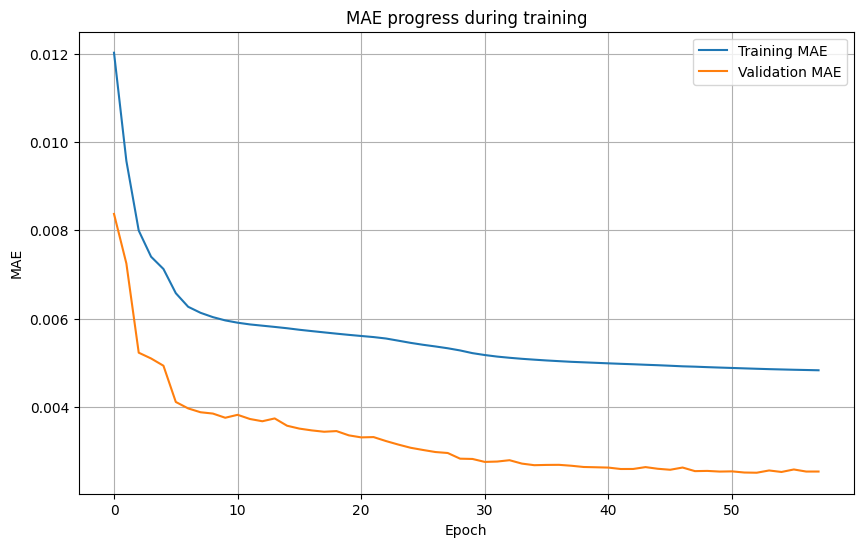

In [20]:
if TRAIN_MODEL:
    history = autoencoder.fit(
        X_train_noisy,
        X_train_clean,
        epochs=100,
        batch_size=64,
        shuffle=True,
        validation_data=(X_test_noisy, X_test_clean),
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True,
            )
        ],
    )

    autoencoder.save(MODEL_PATH)
    print(f"Saved: {MODEL_PATH}")

    plt.figure(figsize=(10, 6))
    plt.plot(history.history["loss"], label="Training MAE")
    plt.plot(history.history["val_loss"], label="Validation MAE")
    plt.title("MAE progress during training")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print(f"Skipping training; using existing model: {MODEL_PATH}")

## Evaluation metrics (MAE / MSE / R2)

The model is trained in log-ratio space, but the main metrics below are
reported again in physical transit depth after applying `from_log_ratio(...)`.


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


autoencoder = keras.models.load_model(MODEL_PATH)
X_reconstructed_log = autoencoder.predict(X_test_noisy)

X_test_clean_physical = from_log_ratio(X_test_clean, ref_flat)
X_reconstructed_physical = from_log_ratio(X_reconstructed_log, ref_flat)

# Compute evaluation metrics in the physical transit-depth space.
mae = mean_absolute_error(X_test_clean_physical, X_reconstructed_physical)
mse = mean_squared_error(X_test_clean_physical, X_reconstructed_physical)
r2 = r2_score(X_test_clean, X_reconstructed_log)
rmse_ppm = np.sqrt(mse) * 1e6
mae_ppm = mae * 1e6

signal_range = float(
    np.ptp(X_test_clean_physical.reshape(-1))
)
signal_range = max(signal_range, LOG_RATIO_EPS)

print("=== EVALUATION METRICS IN PHYSICAL TRANSIT DEPTH ===")
print(f"Mean Absolute Error (MAE): {mae:.6e}")
print(f"Mean Squared Error (MSE): {mse:.6e}")
print(f"Coefficient of Determination (R2): {r2:.6f}")
print(f"MAE [ppm]: {mae_ppm:.3f}")
print(f"RMSE [ppm]: {rmse_ppm:.3f}")
print()
print("=== FRACTION OF GLOBAL PHYSICAL SIGNAL RANGE ===")
print(f"Reference Signal Range: {signal_range:.6e}")
print(f"MAE: {(mae / signal_range) * 100:.6f}%")
print(f"RMSE: {(np.sqrt(mse) / signal_range) * 100:.6f}%")


146127/146127 ━━━━━━━━━━━━━━━━━━━━ 2020s 14ms/step
=== EVALUATION METRICS IN PHYSICAL TRANSIT DEPTH ===
Mean Absolute Error (MAE): 5.653631e-06
Mean Squared Error (MSE): 7.122000e-11
Coefficient of Determination (R2): 0.992015
MAE [ppm]: 5.654
RMSE [ppm]: 8.439

=== FRACTION OF GLOBAL PHYSICAL SIGNAL RANGE ===
Reference Signal Range: 8.094313e-04
MAE: 0.698470%
RMSE: 1.042608%


In [25]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. CONSTANT CONFIGURATION ---
LOG_RATIO_EPS = 1e-12  

# --- 2. CONVERT TO PHYSICAL SPACE ---
X_test_clean_physical = from_log_ratio(X_test_clean, ref_flat)
X_reconstructed_physical = from_log_ratio(X_reconstructed_log, ref_flat)
r2 = r2_score(X_test_clean, X_reconstructed_log)
# --- 3. STANDARD METRICS ---
mae = mean_absolute_error(X_test_clean_physical, X_reconstructed_physical)
mse = mean_squared_error(X_test_clean_physical, X_reconstructed_physical)
rmse = np.sqrt(mse)

# --- 4. SIGNAL RANGE (maximum - ref_flat) ---
# Subtract ref_flat from the global maximum of the clean spectra
max_clean = float(np.max(X_test_clean_physical))
signal_range = max_clean - ref_flat
signal_range = max(signal_range, LOG_RATIO_EPS)

# --- 5. PERCENTAGE METRICS ---
mae_percentage = (mae / signal_range) * 100
rmse_percentage = (rmse / signal_range) * 100

# --- 6. PRINT RESULTS ---
print("=== CLEAN SIGNAL RANGE (MAX - REF) ===")
print(f"Maximum clean value: {max_clean:.6e}")
print(f"Reference value: {ref_flat:.6e}")
print(f"Calculated signal range: {signal_range:.6e}")
print()
print("=== PERCENTAGE METRICS ===")
print(f"MAE (% of range):  {mae_percentage:.6f}%")
print(f"RMSE (% of range): {rmse_percentage:.6f}%")
print(f"R2 = {r2:.6f}")


=== CLEAN SIGNAL RANGE (MAX - REF) ===
Maximum clean value: 3.133781e-03
Reference value: 2.324350e-03
Calculated signal range: 8.094313e-04

=== PERCENTAGE METRICS ===
MAE (% of range):  0.698470%
RMSE (% of range): 1.042608%
$R^2 =$ {{r2}}


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Convert the noisy inputs to physical space for a consistent comparison
X_test_noisy_physical = from_log_ratio(X_test_noisy, ref_flat)

# Select 10 random indices from the test set
num_examples = 10
random_indices = np.random.choice(len(X_test_clean_physical), num_examples, replace=False)

fig, axes = plt.subplots(num_examples, 1, figsize=(10, 4 * num_examples), sharex=True)
if num_examples == 1:
    axes = [axes]

for i, idx in enumerate(random_indices):
    ax = axes[i]
    
    # Extract the arrays in ppm for readability
    noisy_plot = X_test_noisy_physical[idx] * 1e6
    clean_plot = X_test_clean_physical[idx] * 1e6
    recon_plot = X_reconstructed_physical[idx] * 1e6
    
    
    # Plot the spectra
    ax.plot(waves[::-1], noisy_plot, color="#F4A261", alpha=0.5, label="Noisy input")
    ax.plot(waves[::-1], clean_plot, color="#264653", linewidth=2, label="Clean target")
    ax.plot(waves[::-1], recon_plot, color="#2A9D8F", linewidth=2, linestyle="--", label="G-DAE reconstruction")
    
    ax.set_title(f"Test-set example (index {idx})")
    ax.set_ylabel("Transit depth [ppm]")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

axes[-1].set_xlabel("Wavelength [um]")
plt.tight_layout()
plt.show()


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Plot an additional diagnostic directly in log-ratio space

# Select 10 random indices from the test set
num_examples = 10
random_indices = np.random.choice(len(X_test_clean), num_examples, replace=False)

fig, axes = plt.subplots(num_examples, 1, figsize=(10, 4 * num_examples), sharex=True)
if num_examples == 1:
    axes = [axes]

for i, idx in enumerate(random_indices):
    ax = axes[i]
    
    # Extract arrays in log-ratio space
    noisy_plot = X_test_noisy[idx]
    clean_plot = X_test_clean[idx]
    recon_plot = X_reconstructed_log[idx]
    
    # Use spectral-bin indices on the x-axis
    bin_index = np.arange(len(clean_plot))[::-1]
    
    # Plot the spectra
    ax.plot(bin_index, noisy_plot, color="#F4A261", alpha=0.5, label="Noisy input (log ratio)")
    ax.plot(bin_index, clean_plot, color="#264653", linewidth=2, label="Clean target (log ratio)")
    ax.plot(bin_index, recon_plot, color="#2A9D8F", linewidth=2, linestyle="--", label="G-DAE reconstruction (log ratio)")
    
    ax.set_title(f"Test-set example (index {idx})")
    ax.set_ylabel("log(depth / ref_flat)")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

axes[-1].set_xlabel("Spectral bin index")
plt.tight_layout()
plt.show()
